In [1]:
import numpy as np

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.patches import Rectangle

from scipy.optimize import curve_fit

import dexplore as dx 
import xarray as xr
import os
import sys
import glob
import re
from pathlib import Path

sys.path.append(os.path.abspath("steele-lab-analysis-functions"))
import analysis_functions.core as af
from analysis_functions.users.pacome._format_data_xarray import format_data_xarray

from cavity_analysis import cavity_analysis
from cavity_theory import cavity_modes

model = af.ComplexCircle()

Loading BokehJS ...

In [2]:
dx.refresh_bokeh()

Loading BokehJS ...

In [6]:
base_folder = '/home/jovyan/steelelab/measurement_data/4KDIY/Pacome/Long_Time_Evolution'
base_folder = '/home/jovyan/BACKUP/Pacome/Long_Time_Evolution'

In [16]:
file_folder = '2026-06-25_12.23.53_0001_VNA_freqsweep_FFx'
full_path = base_folder + '/' + file_folder
h5_files = sorted(glob.glob(full_path + '/*.h5'))

data = xr.load_dataset(h5_files[0])

dx.interactive_linecut(data, initial_datavar=2)
dx.interactive_linecut_and_colormap(data)

translator = {'Frequency (Hz)':['freq', 'GHz', 1e9]}

data_cavity = format_data_xarray(data, tool='VNA', translator=translator)

Dropping dummy coordinate/dimension 0: "iter"
Dropping dummy coordinate/dimension 1: "None"
New dimensions are: ['freq']


Dropping dummy coordinate/dimension 0: "None"
New dimensions are: ['freq', 'time']


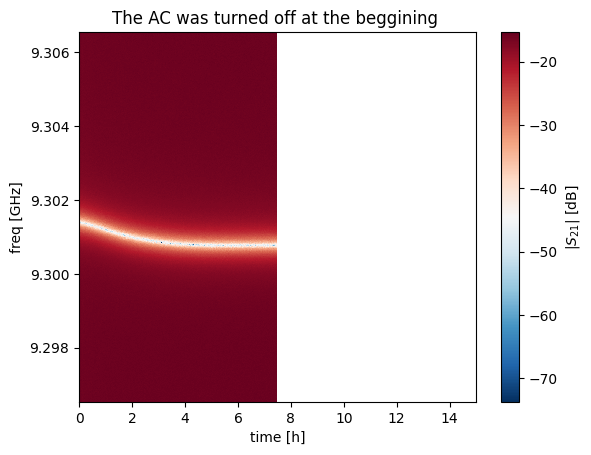

In [20]:
file_folder = '2026-06-29_17.31.42_0002_VNA_freqsweep_FFx'
full_path = base_folder + '/' + file_folder
h5_files = sorted(glob.glob(full_path + '/*.h5'))

data = xr.load_dataset(h5_files[0])

dx.interactive_linecut(data, initial_datavar=2)
dx.interactive_linecut_and_colormap(data)

translator = {'Frequency (Hz)':['freq', 'GHz', 1e9],
              'iter':['time', 'h', 60]}

data_xr = format_data_xarray(data, tool='VNA', translator=translator)
plt.figure()
data_xr.mag.plot(cmap='RdBu_r')
plt.title('The AC was turned off at the beggining')
plt.show()